In [70]:
import numpy as np
import pandas as pd
from plotly.io import show
from matplotlib import pyplot as plt
import mplfinance as mpf
import seaborn as sns
from tabulate import tabulate

import optuna
from optuna.samplers import RandomSampler

from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Backtest import Backtest
from ggTrader.Signals import Signals


Setup

In [84]:
# setup
k = KrakenHistoricalData()

start_equity = 1000
symbols = ["BTC"]
interval = "4h"
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
# start = end - pd.Timedelta(days=30 * 6)
start = pd.to_datetime("2023-01-01").tz_localize('UTC')
# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
# atr_multiplier = 3  # atr multiplier for chandelier exit
# adx_threshold = 25  # trend strength
# ce_high_length = 22  # look back length

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
df_multi = k.get_ohlcv_df(symbols, interval=interval)
# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]
df_bench_mark = pd.DataFrame()
df_bench_mark['close'] = df['close'].copy()
df_bench_mark['equity'] = start_equity * df_bench_mark['close']/(df_bench_mark['close'].iloc[0])
print(df_bench_mark.tail(10))


                                   close       equity
2025-09-28 12:00:00+00:00  110011.101562  6659.549805
2025-09-28 16:00:00+00:00  110353.203125  6680.258301
2025-09-28 20:00:00+00:00  112127.796875  6787.684570
2025-09-29 00:00:00+00:00  111862.500000  6771.624023
2025-09-29 04:00:00+00:00  111863.601562  6771.690918
2025-09-29 08:00:00+00:00  112093.398438  6785.602051
2025-09-29 12:00:00+00:00  113844.000000  6891.575195
2025-09-29 16:00:00+00:00  114358.296875  6922.708008
2025-09-29 20:00:00+00:00  114365.203125  6923.125977
2025-09-30 00:00:00+00:00  114430.601562  6927.084961


Optuna setup

In [72]:
def objective(trial: optuna.Trial):

    # Entry
    # sar_acceleration = trial.suggest_float("sar_acceleration", 0.01, 0.05, step=0.01)
    # sar_maximum = trial.suggest_float("sar_maximum", 0.05, 0.2, step=0.01)
    adx_threshold = trial.suggest_int("adx_threshold", 0, 30)
    adx_length = trial.suggest_int("adx_length", 1, 30)
    # Exit
    atr_multiplier = trial.suggest_float("atr_multiplier", .5, 4, step=0.1)

    ce_high_length = trial.suggest_int("ce_high_length", 1, 30)
    ce_low_length = trial.suggest_int("ce_low_length", 1, 30)
    atr_length = trial.suggest_int("atr_length", 1, 30)

    s = Signals(adx_threshold=adx_threshold,
                adx_length=adx_length,
                atr_multiplier=atr_multiplier,
                atr_length=atr_length,
                ce_high_length=ce_high_length,
                ce_low_length=ce_low_length,
                # sar_acceleration=sar_acceleration,
                # sar_maximum=sar_maximum,
                )

    signals = s.calc_signals(df.copy())
    bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee,start_equity=start_equity)
    stats, profit_df = bt.run()

    sortino = stats['sortino']
    sharpe = stats['sharpe']
    return sharpe

sampler = RandomSampler(seed=42)  # optional seed for reproducibility

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=1000)

[I 2025-11-06 21:15:13,207] A new study created in memory with name: no-name-9d412b68-f7a3-41c4-a2a0-739ff68526ef
[I 2025-11-06 21:15:13,378] Trial 0 finished with value: 4.1336215518387895 and parameters: {'adx_threshold': 11, 'adx_length': 29, 'atr_multiplier': 3.1, 'ce_high_length': 18, 'ce_low_length': 5, 'atr_length': 5}. Best is trial 0 with value: 4.1336215518387895.
[I 2025-11-06 21:15:13,563] Trial 1 finished with value: 4.730800643418801 and parameters: {'adx_threshold': 1, 'adx_length': 26, 'atr_multiplier': 2.6, 'ce_high_length': 22, 'ce_low_length': 1, 'atr_length': 30}. Best is trial 1 with value: 4.730800643418801.
[I 2025-11-06 21:15:13,748] Trial 2 finished with value: 4.956216770469503 and parameters: {'adx_threshold': 25, 'adx_length': 7, 'atr_multiplier': 1.1, 'ce_high_length': 6, 'ce_low_length': 10, 'atr_length': 16}. Best is trial 2 with value: 4.956216770469503.
[I 2025-11-06 21:15:13,920] Trial 3 finished with value: 4.8652806223533105 and parameters: {'adx_thr

Study Results

In [73]:
trials = study.trials_dataframe()
trials.sort_values('value', inplace=True, ascending=False)
trials.columns = trials.columns.str.removeprefix('params_')
trials.drop(['datetime_start','datetime_complete','duration','state'], axis=1, inplace=True)
print(tabulate(trials, headers='keys', tablefmt='github', showindex=False))


|   number |   value |   adx_length |   adx_threshold |   atr_length |   atr_multiplier |   ce_high_length |   ce_low_length |
|----------|---------|--------------|-----------------|--------------|------------------|------------------|-----------------|
|      214 | 7.7195  |           16 |              10 |            3 |              0.8 |               11 |               1 |
|      728 | 7.69253 |            6 |               5 |           12 |              1.2 |               12 |               2 |
|      829 | 7.68163 |           14 |               7 |            2 |              0.9 |                7 |               1 |
|       34 | 7.59506 |            1 |              18 |            5 |              0.8 |               20 |               1 |
|      106 | 7.42395 |            8 |              16 |           10 |              1.4 |               12 |               1 |
|      483 | 7.33195 |            2 |              13 |           13 |              0.9 |               23 |   

In [74]:
best_params = study.best_params
best_value = study.best_value
print(f"\nBest --> Sortino: {best_value:.2f} ")
print(tabulate(best_params.items(), tablefmt="github"))


Best --> Sortino: 7.72 
|----------------|------|
| adx_threshold  | 10   |
| adx_length     | 16   |
| atr_multiplier |  0.8 |
| ce_high_length | 11   |
| ce_low_length  |  1   |
| atr_length     |  3   |


Visualization

In [75]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

fig2 = optuna.visualization.plot_slice(study, params=best_params.keys())
show(fig2)



From the slice plot can notice a few things...

- looks like a lowish ce_low_length value is ideal All sortino values > 8 are ce_low_length = 1
- ATR multiplier <2 also looks ideal as under 2 sortino values reach > 6
- ADX_length and ADX_threshold appear to perform better at low values

Generally there aren't major correlations, but can generally see where there might be better results.  The slice plot does slightly agree with the most hyperparameter importance, since these are the only values that so some sort of correlation to sortino ratio.



In [76]:
fig4 = optuna.visualization.plot_contour(study)
fig4.update_layout(height=1000)
for trace in fig4.data:
    if hasattr(trace, "marker"):
        # ensure markers are visible when mode exists
        if hasattr(trace, "mode") and trace.mode and "markers" not in str(trace.mode):
            trace.mode = f"{trace.mode}+markers"
        trace.marker.size = 1
show(fig4)

fig3 = optuna.visualization.plot_optimization_history(study)
show(fig3)

Seaborn plots

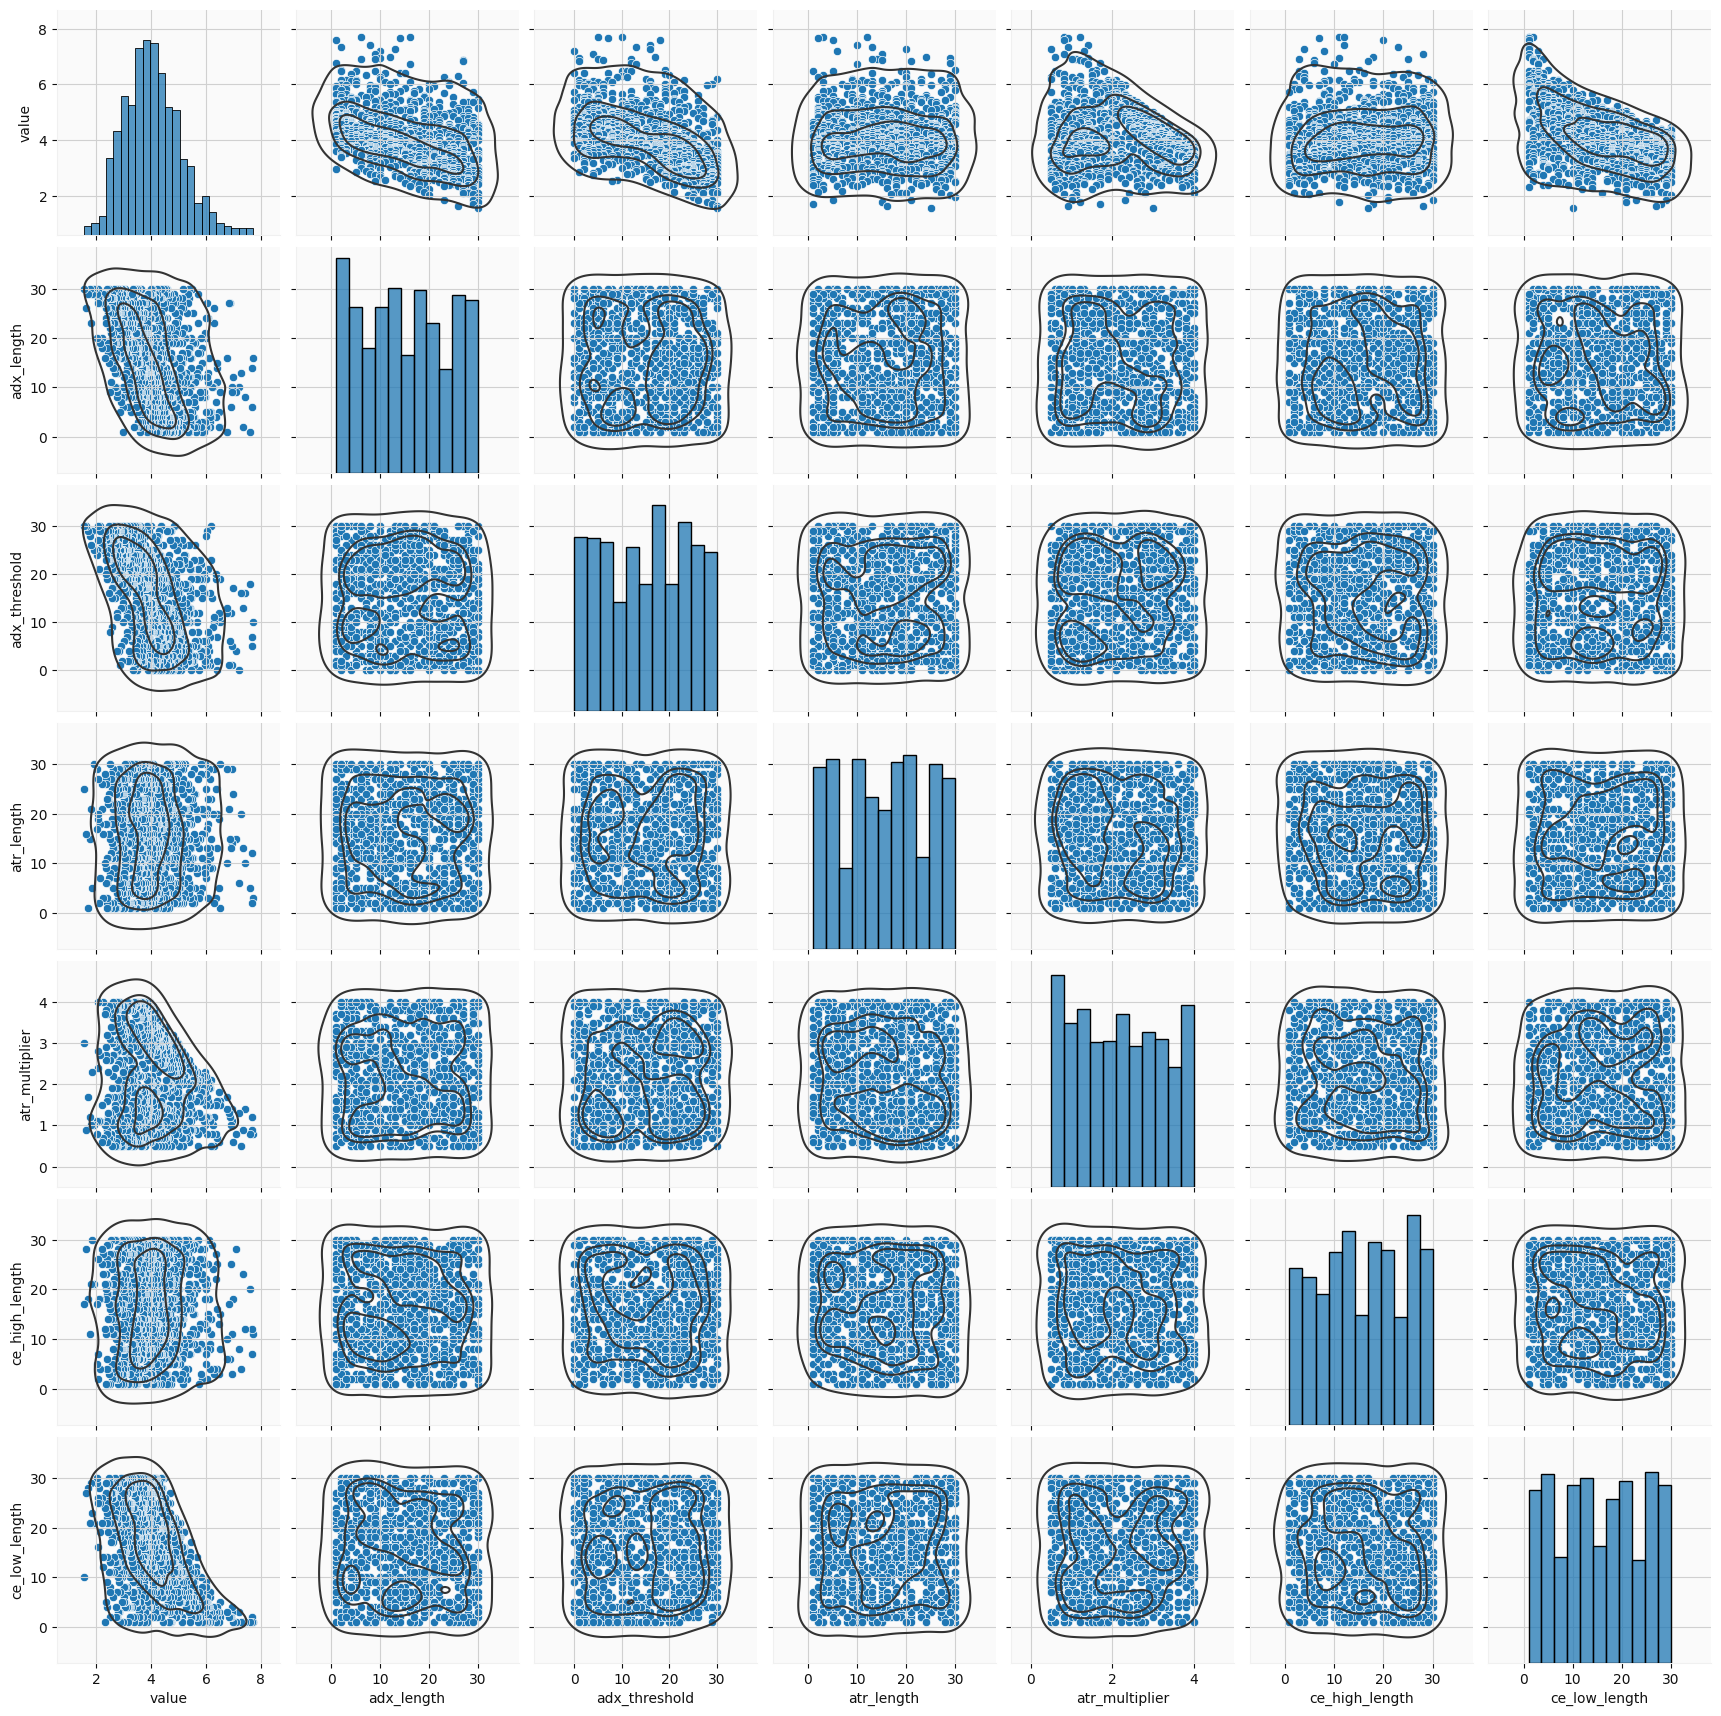

In [77]:
g = sns.pairplot(trials.drop('number', axis=1))
g.map_lower(sns.kdeplot, levels=4, color=".2")
g.map_upper(sns.kdeplot, levels=4, color=".2")
plt.show()

Best Trial Backtest

In [78]:
adx_threshold = best_params['adx_threshold']
adx_length = best_params['adx_length']
atr_multiplier = best_params['atr_multiplier']
atr_length = best_params['atr_length']
ce_high_length = best_params['ce_high_length']
ce_low_length = best_params['ce_low_length']
# sar_acceleration = best_params['sar_acceleration']
# sar_maximum = best_params['sar_maximum']


s = Signals(adx_threshold=adx_threshold,
            adx_length=adx_length,
            atr_multiplier=atr_multiplier,
            atr_length=atr_length,
            ce_high_length=ce_high_length,
            ce_low_length=ce_low_length,
            # sar_acceleration=sar_acceleration,
            # sar_maximum=sar_maximum,
            )
signals = s.calc_signals(df.copy())
bt = Backtest(signals, interval=interval, transaction_fee=transaction_fee)
stats, profit_df = bt.run()
print(f"\n Stats")
print(tabulate(stats.items(), tablefmt="github"))
print(f"\n Profit DataFrame")
print(profit_df.tail().to_string())


 Stats
|------------------|-------------|
| trading_days     |   1003      |
| total_profit     | 165594      |
| total_profit_pct |  16559.4    |
| sharpe           |      7.7195 |
| sortino          |     16.9418 |
| wins             |    286      |
| losses           |     36      |
| win_rate         |     88.8199 |

 Profit DataFrame
                           Entry_Price  Exit_Price          close   Returns  Window_Profit         Equity
2025-09-29 08:00:00+00:00          0.0         0.0  112093.398438  0.002054            NaN  163191.216364
2025-09-29 12:00:00+00:00          0.0         0.0  113844.000000  0.015617            NaN  165739.830309
2025-09-29 16:00:00+00:00          0.0         0.0  114358.296875  0.004518            NaN  166488.569608
2025-09-29 20:00:00+00:00          0.0         0.0  114365.203125  0.000060            NaN  166498.624075
2025-09-30 00:00:00+00:00          0.0         0.0  114430.601562  0.000572       0.033632  166593.834414


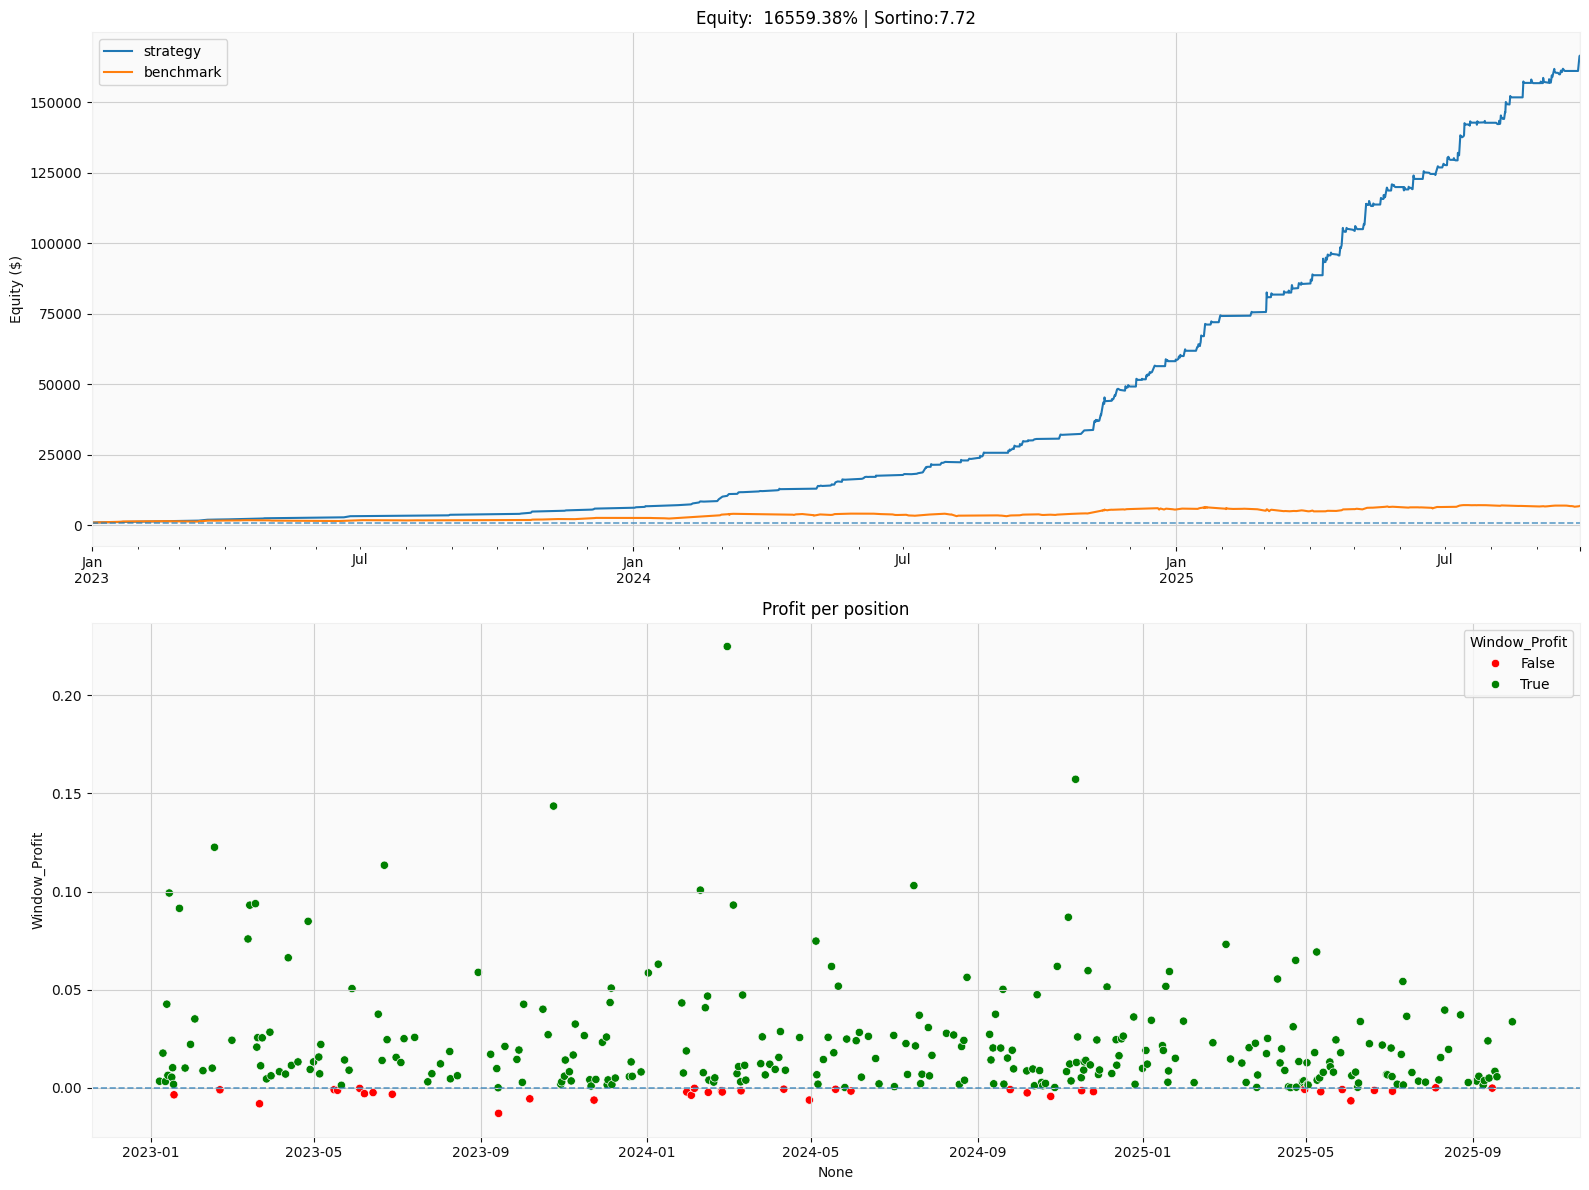

In [87]:
# plots
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
profit_df['Equity'].plot(ax=axes[0], title=f'Equity:  {stats["total_profit_pct"]:.2f}% | Sortino:{best_value:.2f}',label='strategy')
df_bench_mark['equity'].plot(ax=axes[0], label='benchmark', secondary_y=False)
axes[0].set_ylabel('Equity ($)')
axes[0].legend()
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
window_profit = profit_df['Window_Profit'] * 100
sns.scatterplot(x=profit_df.index, y='Window_Profit', data=profit_df, ax=axes[1], hue=profit_df['Window_Profit']>0, palette={True: 'green', False: 'red'})
axes[1].set_title('Profit per position')
axes[1].axhline(0.0, linestyle='--', linewidth=1.2, alpha=0.7)
plt.tight_layout()
plt.show()

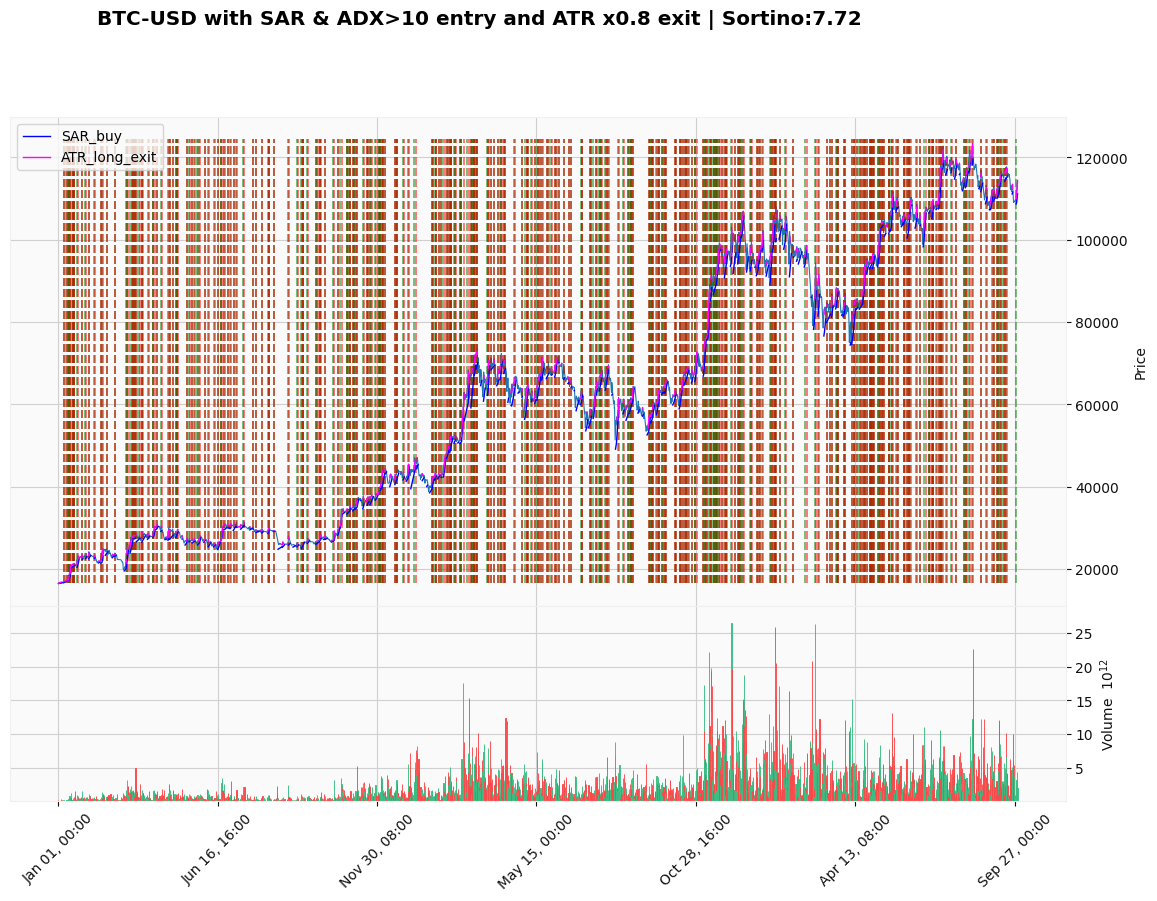

In [80]:
# Combine and color differently
##  Boolean where in position

y1_arr = signals['close'].values
filtered_entry = signals['filtered_entry']
filtered_exit = signals['filtered_exit']
in_position = signals['in_position']

y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]
# Build sorted timestamps with colors (keeps colors aligned with dates)
entries = [(ts, 'g') for ts in filtered_entry[filtered_entry].index]
exits   = [(ts, 'r') for ts in filtered_exit[filtered_exit].index]
pairs = sorted(entries + exits, key=lambda x: x[0])

# Extract in order expected by mplfinance
vline_dates  = [ts for ts, _ in pairs]
vline_colors = [c  for _,  c in pairs]

adx_line = pd.Series(adx_threshold, index=df.index)
zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(signals['sar'], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),


]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=True,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 12),
    figscale=1.7,
    tight_layout=False,
    title=f"{symbols[0]}-USD with SAR & ADX>{adx_threshold} entry and ATR x{atr_multiplier:.1f} exit | Sortino:{best_value:.2f}",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,

)